### SETUP MODULES
The following modules include imports / IBM account initialization that the homework requires.

In [6]:
# -----------------------------------
# IMPORTS REQUIRED FOR THE ASSIGNMENT
# -----------------------------------
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import transpile


In [7]:
# -------------------------------
# ACCOUNT LINK TO QISKIT SERVVICE
# -------------------------------
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="hPp27YYsQIgcnApUBSMsQnMIBL-VkUwIHN5-aOHeKnkF",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/333c753dd333451a9f49f7993cede44f:95cf404b-9d0a-49c0-9690-bc0a1b6fc509::",
    overwrite=True,
    set_as_default=True
)

service = QiskitRuntimeService()
print("Connected to IBM Quantum.")

Connected to IBM Quantum.


### PART 1
In this part, I have:

- Chosen 2 available backends
- Read / store all properties from each qubit
- Find the min, max, median and mean for each property

In [8]:
# -------------------------------
# INITIALZING / CHOOSING BACKENDS
# -------------------------------
available_backends = service.backends(
    simulator=False,
    operational=True
)

# Viewing all potential backends
for backend in available_backends:
    print(backend)

# Selecting backend here
backend_one = service.backend('ibm_fez')
backend_two = service.backend('ibm_marrakesh')

<IBMBackend('ibm_fez')>
<IBMBackend('ibm_marrakesh')>
<IBMBackend('ibm_kingston')>


In [9]:
# ---------------------------------
# READING BACKEND CHARACTERIZATIONS
# ---------------------------------
device_info = {
    "ibm_fez": {"T1": [], "T2": [], "Readout": []},
    "ibm_marrakesh": {"T1": [], "T2": [], "Readout": []},
}

# The number of qubits for both backends
num_qubits_b1 = backend_one.num_qubits
num_qubits_b2 = backend_two.num_qubits

# Preparing the properties for each backend to be read from
backend_one_prop = backend_one.properties(refresh=True)
backend_two_prop = backend_two.properties(refresh=True)

# Reading error from IBM_FEZ
for qubit in range(num_qubits_b1):
    qubit_properties = backend_one_prop.qubit_property(qubit)
    if "T1" in qubit_properties:
        device_info["ibm_fez"]["T1"].append(qubit_properties["T1"][0] * 1e6)
    else:
        device_info["ibm_fez"]["T1"].append(np.nan)

    if "T2" in qubit_properties:
        device_info["ibm_fez"]["T2"].append(qubit_properties["T2"][0] * 1e6)
    else:
        device_info["ibm_fez"]["T2"].append(np.nan)

    if "readout_error" in qubit_properties:
        device_info["ibm_fez"]["Readout"].append(qubit_properties["readout_error"][0] * 100)
    else:
        device_info["ibm_fez"]["Readout"].append(np.nan)

# Reading error from IBM_MERRAKESH
for qubit in range(num_qubits_b2):
    qubit_properties = backend_two_prop.qubit_property(qubit)

    if "T1" in qubit_properties:
        device_info["ibm_marrakesh"]["T1"].append(qubit_properties["T1"][0] * 1e6)
    else:
        device_info["ibm_marrakesh"]["T1"].append(np.nan)

    if "T2" in qubit_properties:
        device_info["ibm_marrakesh"]["T2"].append(qubit_properties["T2"][0] * 1e6)
    else:
        device_info["ibm_marrakesh"]["T2"].append(np.nan)

    if "readout_error" in qubit_properties:
        device_info["ibm_marrakesh"]["Readout"].append(qubit_properties["readout_error"][0] * 100)
    else:
        device_info["ibm_marrakesh"]["Readout"].append(np.nan)
   
# fez_df = pd.DataFrame(device_info["ibm_fez"])
# merrakesh_df = pd.DataFrame(device_info["ibm_marrakesh"])
# display(fez_df.style.set_caption("IBM FEZ"))
# display(merrakesh_df.style.set_caption("IBM MARRAKESH"))

In [10]:
# ---------------------------------
# READING GATE ERRORS
# ---------------------------------
target_fez = backend_one.target
target_marrakesh = backend_two.target

# Adding gate error field to each device
device_info["ibm_fez"]["SingleQubitGateErrors"] = {}
device_info["ibm_fez"]["TwoQubitGateErrors"] = {}
device_info["ibm_marrakesh"]["SingleQubitGateErrors"] = {}
device_info["ibm_marrakesh"]["TwoQubitGateErrors"] = {}

# Excluding non-computational/global gates
excluded_instructions = {
    "measure",
    "measure_reset",
    "measure_reset_2",
    "reset",
    "reset_2",
    "delay",
    "barrier"
}

# Reading gate errors from IBM_FEZ
for gate_name in sorted(target_fez.operation_names):
    if gate_name in excluded_instructions:
        continue

    qubit_arguments = target_fez.qargs_for_operation_name(gate_name)
    if qubit_arguments is None:
        continue

    for qubits_used in qubit_arguments:
        gate_properties = target_fez[gate_name][qubits_used]
        if gate_properties is None or gate_properties.error is None:
            error = np.nan
        else:
            error = gate_properties.error * 100

        if len(qubits_used) == 1:
            device_info["ibm_fez"]["SingleQubitGateErrors"].setdefault(gate_name, []).append(error)
        elif len(qubits_used) == 2:
            device_info["ibm_fez"]["TwoQubitGateErrors"].setdefault(gate_name, []).append(error)

# Reading gate errors from IBM_MARRAKESH
for gate_name in sorted(target_marrakesh.operation_names):
    if gate_name in excluded_instructions:
        continue

    qubit_arguments = target_marrakesh.qargs_for_operation_name(gate_name)
    if qubit_arguments is None:
        continue

    for qubits_used in qubit_arguments:
        gate_properties = target_marrakesh[gate_name][qubits_used]
        if gate_properties is None or gate_properties.error is None:
            error = np.nan
        else:
            error = gate_properties.error * 100

        if len(qubits_used) == 1:
            device_info["ibm_marrakesh"]["SingleQubitGateErrors"].setdefault(gate_name, []).append(error)
        elif len(qubits_used) == 2:
            device_info["ibm_marrakesh"]["TwoQubitGateErrors"].setdefault(gate_name, []).append(error)

In [11]:
# ----------------------------------
# SUMMARIZING MIN, MAX, MEAN, MEDIAN
# ----------------------------------

# Helper function to summarize properties of a backend
def summarize(values):
    np_array = np.array(values)
    return {
        "min": np.nanmin(np_array),
        "max": np.nanmax(np_array),
        "mean": np.nanmean(np_array),
        "median": np.nanmedian(np_array),
    }

# Summay for the Fez backend
fez_summary = {
    "T1": summarize(device_info["ibm_fez"]["T1"]),
    "T2": summarize(device_info["ibm_fez"]["T2"]),
    "Readout": summarize(device_info["ibm_fez"]["Readout"]),
}
for gate_name, errors in device_info["ibm_fez"]["SingleQubitGateErrors"].items():
    fez_summary[f"{gate_name.upper()} Error"] = summarize(errors)
for gate_name, errors in device_info["ibm_fez"]["TwoQubitGateErrors"].items():
    fez_summary[f"{gate_name.upper()} Error"] = summarize(errors)

# Summay for the Marrakesh backend
marrakesh_summary = {
    "T1": summarize(device_info["ibm_marrakesh"]["T1"]),
    "T2": summarize(device_info["ibm_marrakesh"]["T2"]),
    "Readout": summarize(device_info["ibm_marrakesh"]["Readout"]),
}
for gate_name, errors in device_info["ibm_marrakesh"]["SingleQubitGateErrors"].items():
    marrakesh_summary[f"{gate_name.upper()} Error"] = summarize(errors)
for gate_name, errors in device_info["ibm_marrakesh"]["TwoQubitGateErrors"].items():
    marrakesh_summary[f"{gate_name.upper()} Error"] = summarize(errors)

fez_summary_df = pd.DataFrame(fez_summary) 
marrakesh_summary_df = pd.DataFrame(marrakesh_summary)

display(fez_summary_df.style.set_caption("IBM FEZ SUMMARY"))
display(marrakesh_summary_df.style.set_caption("IBM MARRAKESH SUMMARY"))

,T1,T2,Readout,ID Error,MEASURE_2 Error,RZ Error,SX Error,X Error,XSLOW Error,CZ Error
min,17.986278,5.531148,0.195312,0.011715,0.170898,0.000000,0.011715,0.011715,0.011715,0.151078
max,288.692622,274.328309,29.418945,100.000000,45.117188,0.000000,100.000000,100.000000,100.000000,100.000000
mean,131.543605,97.037717,1.882856,0.686011,3.099960,0.000000,0.686011,0.686011,0.686011,3.301351
median,128.214680,89.025123,0.927734,0.033224,1.269531,0.000000,0.033224,0.033224,0.033224,0.282571


,T1,T2,Readout,ID Error,MEASURE_2 Error,RZ Error,SX Error,X Error,XSLOW Error,CZ Error
min,6.523990,3.569478,0.122070,0.012328,0.170898,0.000000,0.012328,0.012328,0.012328,0.120652
max,400.748038,483.719489,50.000000,100.000000,50.415039,0.000000,100.000000,100.000000,100.000000,100.000000
mean,174.082284,103.016393,3.118270,1.975929,4.201097,0.000000,1.975929,1.975929,1.975929,4.681559
median,164.907706,71.442077,1.074219,0.039917,1.721191,0.000000,0.039917,0.039917,0.039917,0.342797


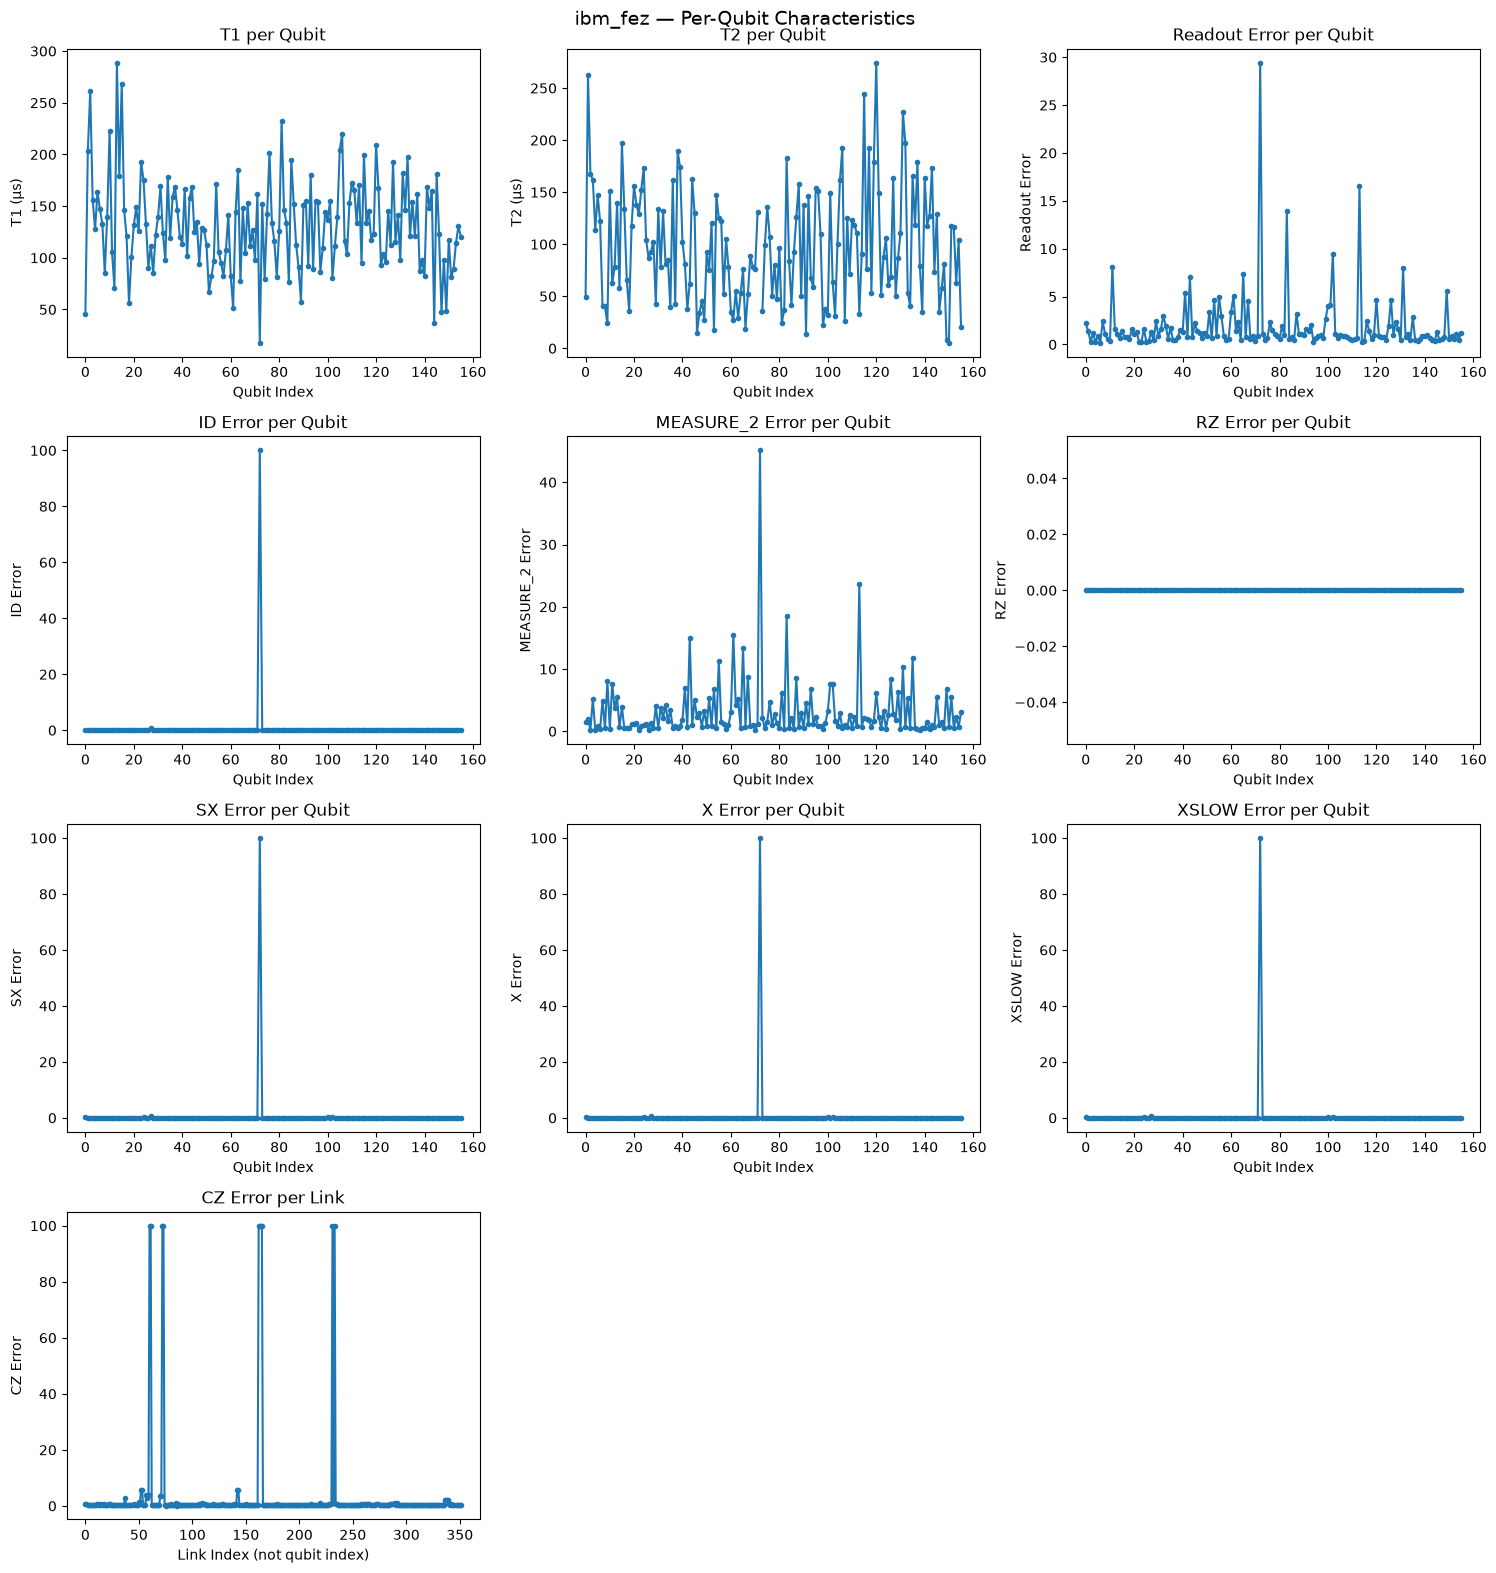

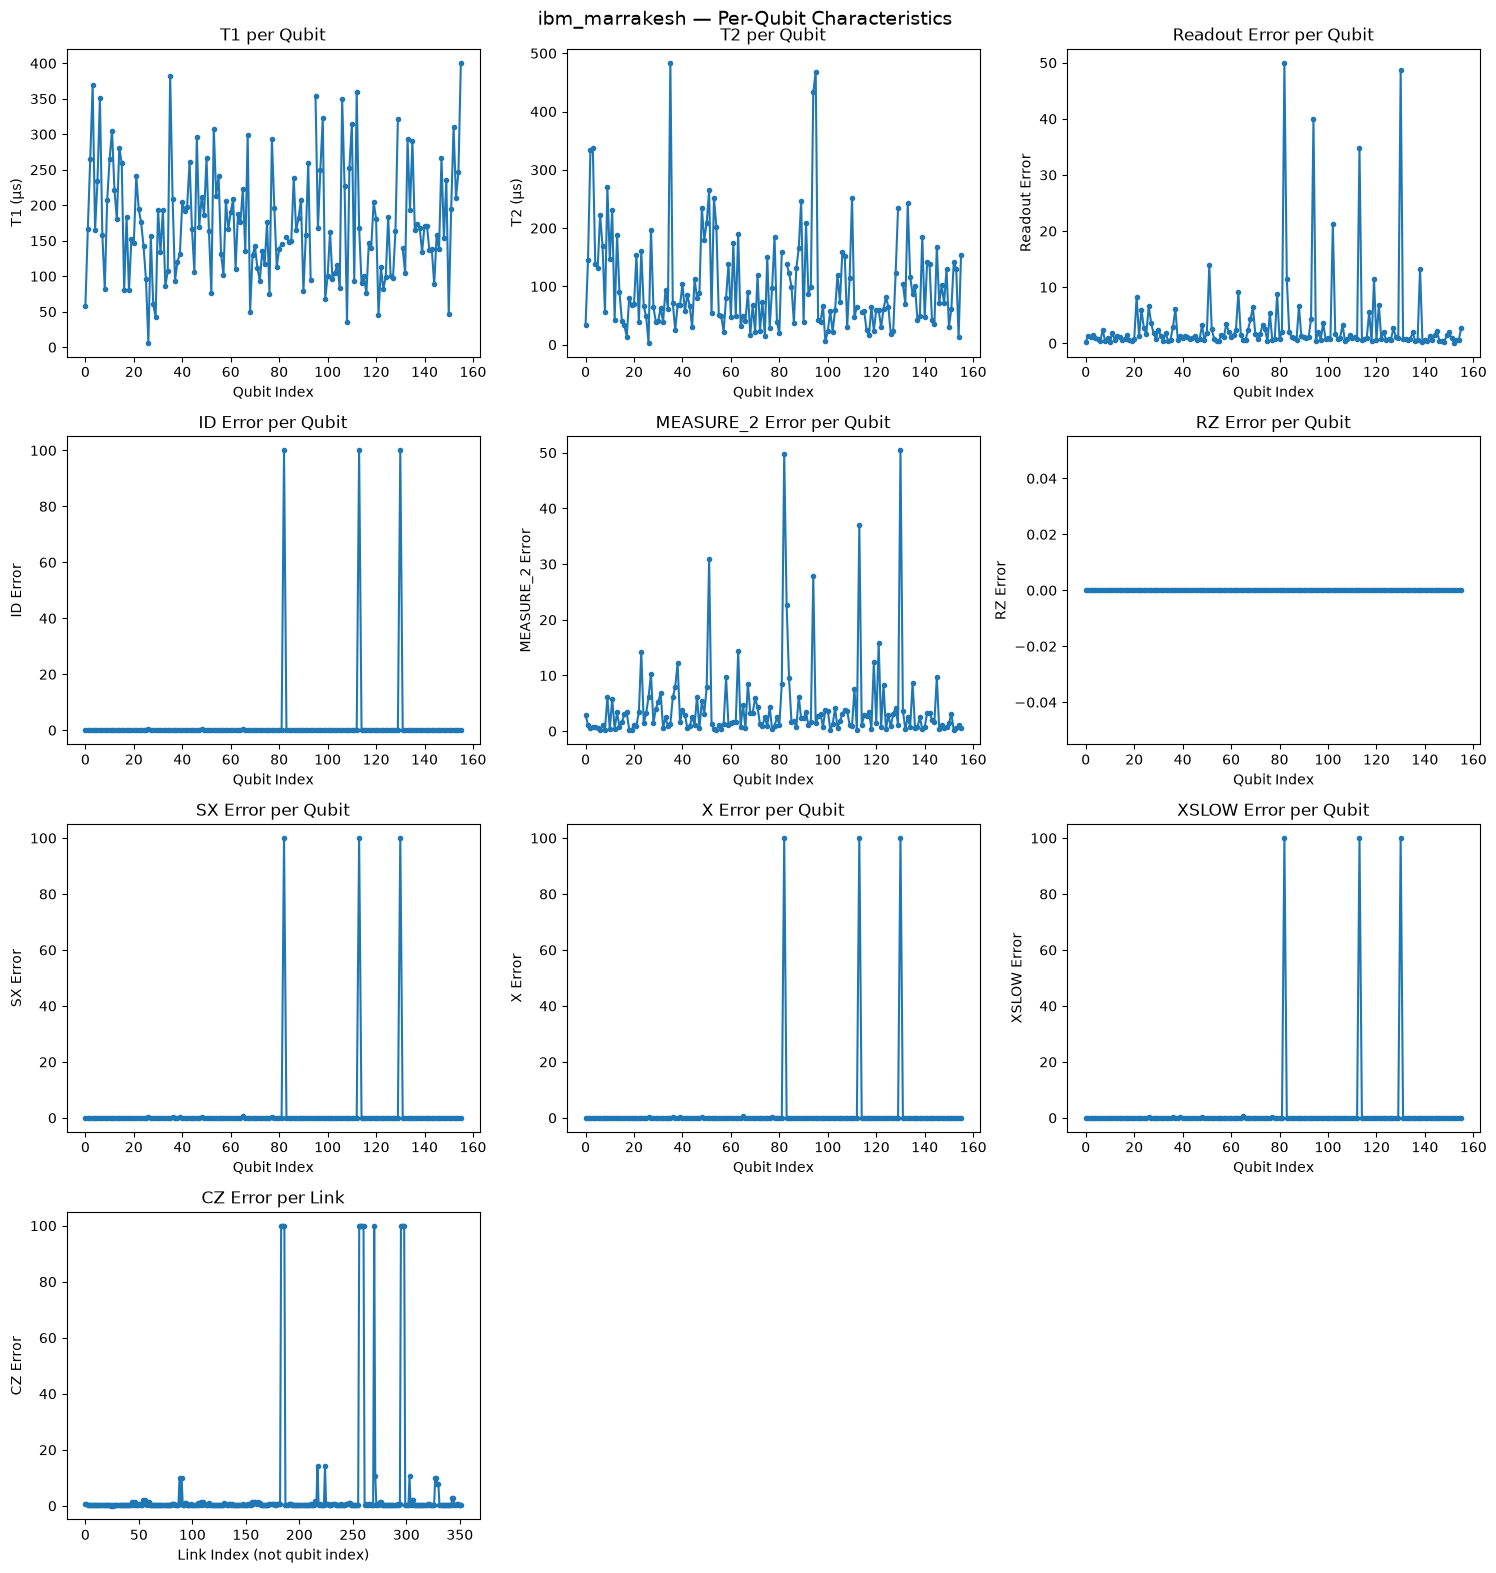

In [12]:
# ----------------------------------
# VISUALIZING PER-QUBIT DATA
# ----------------------------------
import matplotlib.pyplot as plt

devices = ["ibm_fez", "ibm_marrakesh"]

for device in devices:
    plots = [
        ("T1 per Qubit", "T1 (µs)", device_info[device]["T1"], "Qubit Index"),
        ("T2 per Qubit", "T2 (µs)", device_info[device]["T2"], "Qubit Index"),
        ("Readout Error per Qubit", "Readout Error", device_info[device]["Readout"], "Qubit Index"),
    ]

    for gate_name, errors in device_info[device]["SingleQubitGateErrors"].items():
        plots.append((f"{gate_name.upper()} Error per Qubit", f"{gate_name.upper()} Error", errors, "Qubit Index"))

    for gate_name, errors in device_info[device]["TwoQubitGateErrors"].items():
        plots.append((f"{gate_name.upper()} Error per Link", f"{gate_name.upper()} Error", errors, "Link Index (not qubit index)"))

    cols = 3
    rows = -(-len(plots) // cols)  # ceiling division, so extra plots get their own row

    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    axes = axes.flatten()

    for ax, (title, ylabel, values, xlabel) in zip(axes, plots):
        ax.plot(values, marker='.', linestyle='-')
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

    for ax in axes[len(plots):]:
        ax.axis("off")  # hide any leftover empty subplot slots

    fig.suptitle(f"{device} — Per-Qubit Characteristics", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{device}_per_qubit_characteristics.png", dpi=150, bbox_inches="tight")
    plt.show()

### PART 2
In this part, I have:

- Made a GHZ circuit in a Ideal Simulation
- Made a GHZ circuit in a Noisy Simulation
- Defined fidelity in my own words

In [13]:
# -----------------------------------
# CREATING GHZ CIRCUIT 
# -----------------------------------
def createGHZ(n):
    ghz_circuit = QuantumCircuit(n)
    ghz_circuit.h(0)
    for qubit in range(1, n):
        ghz_circuit.cx(0, qubit)
    ghz_circuit.measure_all()
    return ghz_circuit

In [14]:
# -----------------------------------
# IDEAL SIMULATOR FOR GHZ CIRCUIT 
# -----------------------------------
ideal_simulator = AerSimulator()
ideal_sampler = Sampler(mode=ideal_simulator)

ghz_ideal_results = {}
shots = 10000

for num_of_qubits in range(2, 21):
    sim = AerSimulator()
    ideal_job = ideal_sampler.run([createGHZ(num_of_qubits)], shots=shots)
    ideal_result = ideal_job.result()
    ideal_counts = ideal_result[0].data.meas.get_counts()
    ghz_ideal_results[num_of_qubits] = ideal_counts
    print(f"n={num_of_qubits} done")

n=2 done
n=3 done
n=4 done
n=5 done
n=6 done
n=7 done
n=8 done
n=9 done
n=10 done
n=11 done
n=12 done
n=13 done
n=14 done
n=15 done
n=16 done
n=17 done
n=18 done
n=19 done
n=20 done


In [15]:
# -----------------------------------
# NOISY SIMULATOR FOR GHZ CIRCUIT 
# -----------------------------------
print("1")
noisy_simulator = AerSimulator.from_backend(backend_one)
print("2")
noisy_sampler = Sampler(mode=noisy_simulator)

ghz_noisy_results = {}          
shots = 10000
print("3")

for num_of_qubits in range(2, 21):
    noisy_compiled_circuit = transpile(createGHZ(num_of_qubits), backend=noisy_simulator, optimization_level=1)
    noisy_job = noisy_sampler.run([noisy_compiled_circuit], shots=shots)
    noisy_result = noisy_job.result()
    noisy_counts = noisy_result[0].data.meas.get_counts()
    ghz_noisy_results[num_of_qubits] = noisy_counts   
    print(f"n={num_of_qubits} done")


1
2
3
n=2 done
n=3 done
n=4 done
n=5 done
n=6 done
n=7 done
n=8 done
n=9 done
n=10 done
n=11 done
n=12 done
n=13 done
n=14 done
n=15 done
n=16 done
n=17 done
n=18 done
n=19 done
n=20 done


In [16]:
# -----------------------------------
# CALCULATING FIDELITY
# -----------------------------------

# This function turns all counts into a probability
def counts_to_probabilities(counts, shots):
    probabilities = {}
    for bitstring, count in counts.items():
        probabilities[bitstring] = count / shots
    return probabilities

# This function is the TVD formula
def total_variation_distance(p, q):
    all_bitstrings = set(p.keys()) | set(q.keys())
    
    total_difference = 0
    for b in all_bitstrings:
        p_value = p.get(b, 0)
        q_value = q.get(b, 0)
        difference = abs(p_value - q_value)
        total_difference += difference
    
    return 0.5 * total_difference

# Calculate fidelity given TVD
def fidelity(p, q):
    return 1 - total_variation_distance(p, q)

# Using this as a perfect benchmark to compare fidelity of both ideal and noisy sim
def ideal_ghz_distribution(n):
    return {"0" * n: 0.5, "1" * n: 0.5}

# Computing fidelity for every "n" amount of qubits
ideal_fidelities = {}
noisy_fidelities = {}

for n in range(2, 21):
    target_dist = ideal_ghz_distribution(n)
    ideal_probs = counts_to_probabilities(ghz_ideal_results[n], shots)
    noisy_probs = counts_to_probabilities(ghz_noisy_results[n], shots)

    ideal_fidelities[n] = fidelity(ideal_probs, target_dist)
    noisy_fidelities[n] = fidelity(noisy_probs, target_dist)

In [17]:
# -----------------------------------
# TWO QUBIT GATE VS. CIRCUIT DEPTH
# -----------------------------------
two_qubit_gates = []
ghz_circuit_depth = []
ghz_transpiled_circuits = {}

for num_of_qubits in range(2, 21):
    ghz_transpiled_circuits[num_of_qubits] = transpile(createGHZ(num_of_qubits), backend=noisy_simulator, optimization_level=1)
    transpiled_qc = ghz_transpiled_circuits[num_of_qubits]
    two_qubit_gates.append(transpiled_qc.count_ops().get('cz', 0))
    ghz_circuit_depth.append(transpiled_qc.depth())

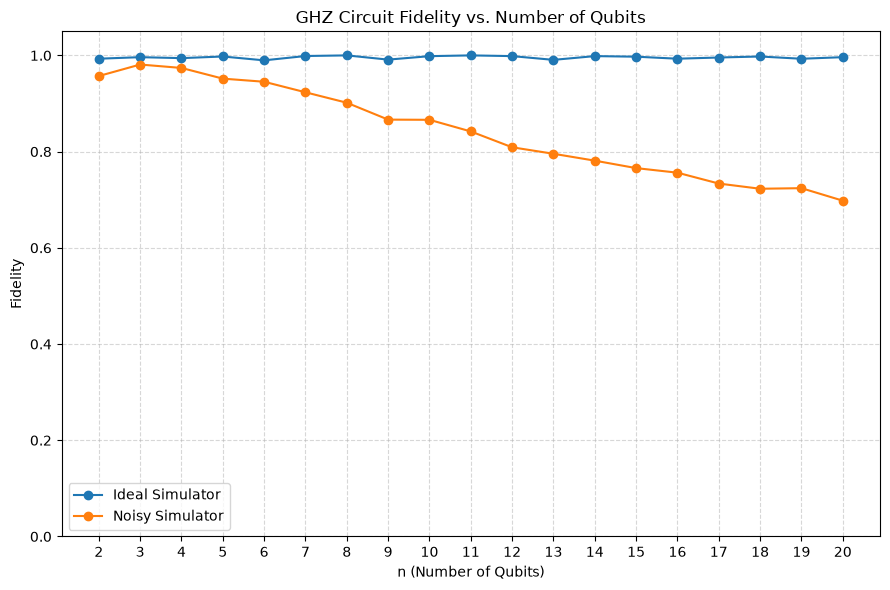

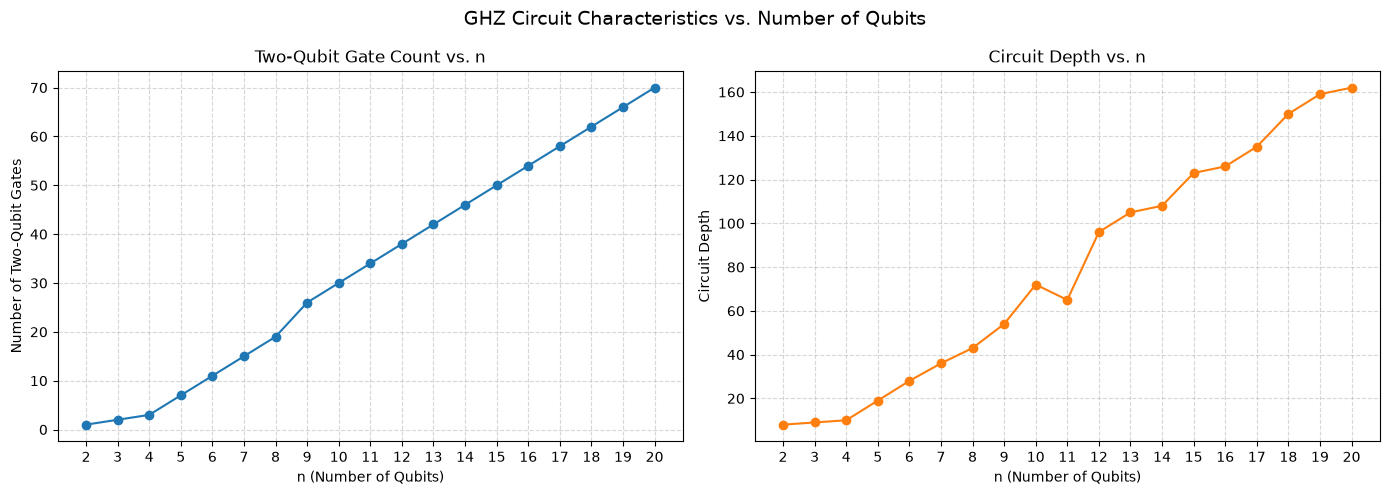

In [18]:
# -----------------------------------
# FIGURE 1
# -----------------------------------
n_values = list(range(2, 21))
ideal_values = [ideal_fidelities[n] for n in n_values]
noisy_values = [noisy_fidelities[n] for n in n_values]

plt.figure(figsize=(9, 6))
plt.plot(n_values, ideal_values, marker='o', label='Ideal Simulator')
plt.plot(n_values, noisy_values, marker='o', label='Noisy Simulator')
plt.xlabel("n (Number of Qubits)")
plt.ylabel("Fidelity")
plt.title("GHZ Circuit Fidelity vs. Number of Qubits")
plt.xticks(n_values)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("figure1_fidelity_vs_n.png", dpi=150, bbox_inches="tight")
plt.show()

# -----------------------------------
# FIGURE 2
# -----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(n_values, two_qubit_gates, marker='o', color='tab:blue')
axes[0].set_xlabel("n (Number of Qubits)")
axes[0].set_ylabel("Number of Two-Qubit Gates")
axes[0].set_title("Two-Qubit Gate Count vs. n")
axes[0].set_xticks(n_values)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(n_values, ghz_circuit_depth, marker='o', color='tab:orange')
axes[1].set_xlabel("n (Number of Qubits)")
axes[1].set_ylabel("Circuit Depth")
axes[1].set_title("Circuit Depth vs. n")
axes[1].set_xticks(n_values)
axes[1].grid(True, linestyle='--', alpha=0.5)

fig.suptitle("GHZ Circuit Characteristics vs. Number of Qubits", fontsize=14)
plt.tight_layout()
plt.savefig("figure2_circuit_characteristics_vs_n.png", dpi=150, bbox_inches="tight")
plt.show()

### PART 3
In this part, I have:

RAHHHH

In [32]:
# ----------------------------------
# COMPUTING ESP
# ----------------------------------
def compute_esp(circuit, backend):
    target = backend.target
    fidelity = 1.0

    # Loops through every instruction in the circuit (like CNOT and stuff other gates like that)
    for instruction in circuit.data:
        gate_name = instruction.operation.name
        
        qubits_used = []

        # Finds the qubits used in the instruction
        for qubit in instruction.qubits:
            qubits_used.append(circuit.find_bit(qubit).index)
        qubits_used = tuple(qubits_used)
        
        if gate_name not in target.operation_names:
            continue

        # Gets the error from the gate / qubits
        gate_properties = target[gate_name].get(qubits_used)
        if gate_properties is None or gate_properties.error is None:
            continue

        # Fidelity is computed based on each gate error
        fidelity *= (1 - gate_properties.error)

    return fidelity

esp_values = {}
for num_of_qubits in range(2, 21):
    esp_values[num_of_qubits] = compute_esp(ghz_transpiled_circuits[num_of_qubits], backend_one)

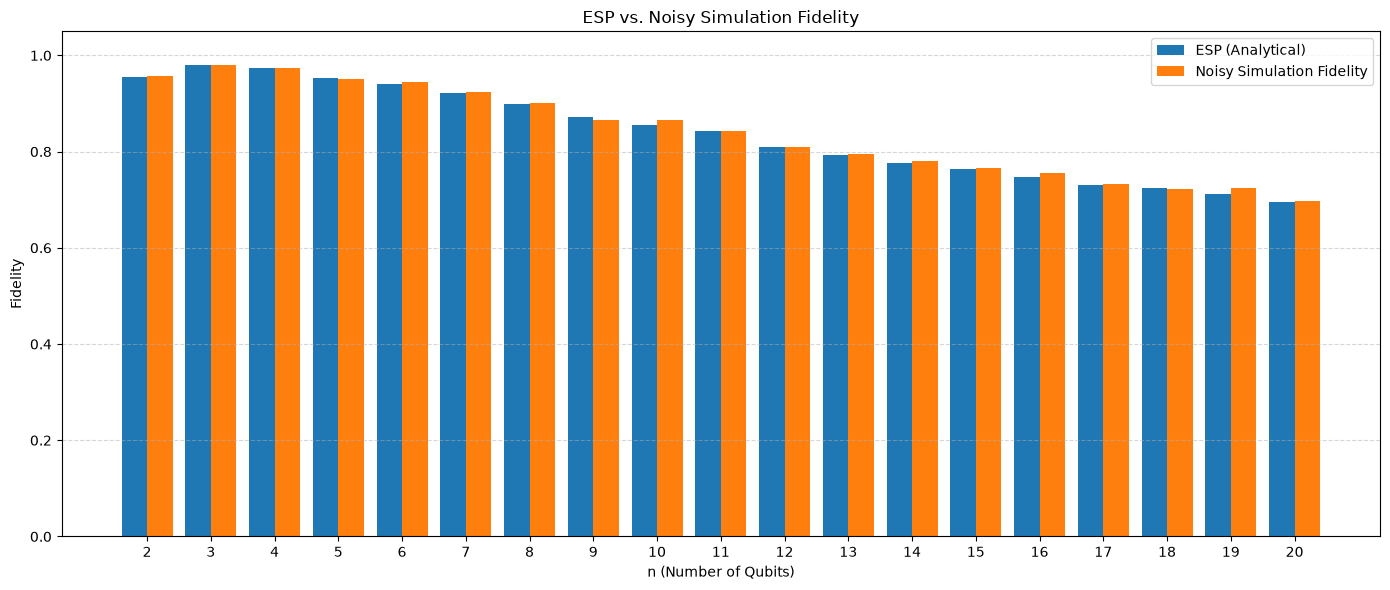

In [33]:
# ----------------------------------
# COMPUTING ESP
# ----------------------------------
n_values = list(range(2, 21))
esp_list = [esp_values[n] for n in n_values]
noisy_fidelity_list = [noisy_fidelities[n] for n in n_values]

x = np.arange(len(n_values))
width = 0.4

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, esp_list, width, label='ESP (Analytical)')
plt.bar(x + width/2, noisy_fidelity_list, width, label='Noisy Simulation Fidelity')

plt.xlabel("n (Number of Qubits)")
plt.ylabel("Fidelity")
plt.title("ESP vs. Noisy Simulation Fidelity")
plt.xticks(x, n_values)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("figure3_esp_vs_noisy_fidelity.png", dpi=150, bbox_inches="tight")
plt.show()